In [1]:
import os
import argparse
import math
import re
from typing import List, Dict, Optional
import pandas as pd
from tqdm import tqdm
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"

import ctypes

# Add this BEFORE 'import torch'
try:
    # This manually loads the core C++ library for torch
    ctypes.WinDLL(os.path.join(os.environ['CONDA_PREFIX'], 'Lib', 'site-packages', 'torch', 'lib', 'c10.dll'))
except Exception:
    pass

import torch
import torch.nn.functional as F
from dotenv import load_dotenv
load_dotenv()

from openai import OpenAI
import requests
import chromadb
from chromadb.utils import embedding_functions

from data_fetchers import load_dataset_into_memory

In [2]:
import sys
print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
import torch
print(f"Torch version: {torch.__version__}")

Python version: 3.11.4 | packaged by Anaconda, Inc. | (main, Jul  5 2023, 13:38:37) [MSC v.1916 64 bit (AMD64)]
Executable: C:\Users\cfavr\anaconda3\python.exe
Torch version: 2.5.1+cu121


In [6]:

# Configuration
ENDPOINT_URL = "https://yyirs15si60zuagp.us-east-1.aws.endpoints.huggingface.cloud" # Endpoint URL + version
HF_TOKEN = os.getenv("HF_API_TOKEN") # Your Hugging Face Hub token from hf.co/settings/tokens

HF_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

api_url = f"https://router.huggingface.co/pipeline/feature-extraction/{HF_MODEL}"
headers = {"Authorization": f"Bearer {HF_TOKEN}"}

def query(texts):
    response = requests.post(api_url, headers=headers, json={"inputs": texts, "options":{"wait_for_model":True}})
    return response.json()


from huggingface_hub import InferenceClient

client = InferenceClient(model= ENDPOINT_URL, token=HF_TOKEN)

In [7]:
def get_embeddings(texts: List[str]) -> List[List[float]]:
	if isinstance(texts, str):
		texts = [texts]
    
	all_embeddings = []

	batch_size=32
	for i in range(0, len(texts), batch_size):
		batch = texts[i:i + batch_size]
		results = client.feature_extraction(batch)
        
		# results is typically List[List[float]]
		all_embeddings.extend(results)
		
	return all_embeddings


def decompose_string_to_per_each_new_token_embeddings(text: str) -> List[List[float]]:
	tokens = text.split()  # simple whitespace tokenizer; replace with more robust one if needed
	cache_toks = []
	each_new_text = []
	for tok in tokens:
		cache_toks.append(tok)
		each_new_text.append(' '.join(cache_toks))

	emb = get_embeddings(each_new_text)
	return emb


def shift_embeds(embs: List[List[float]], fill_with_nan: bool = True) -> List[List[float]]:
	"""Return a list of the same length as `embs` where each row is the previous cumulative embedding.

	For i in [1..n]: result[i] = embs[i-1]
	The first row (i == 0) is filled with NaNs by default, or zeros if `fill_with_nan` is False.
	"""
	embs_shifted = np.vstack([embs[:1], embs[:-1]])
	if fill_with_nan:
		embs_shifted[0] = np.nan
	else:
		embs_shifted[0] = 0
	return embs_shifted


def per_token_embedding_differences(embs: List[List[float]], fill_with_nan: bool = True) -> List[List[float]]:
	"""Return a list of the same length as `embs` where each row is the difference
	between the previous cumulative embedding and the current one.

	For i in [1..n]: result[i] = embs[i] - embs[i-1]
	The first row (i == 0) is filled with NaNs by default, or zeros if
	`fill_with_nan` is False.

	"""
	embs_shifted = np.vstack([embs[:1], embs[:-1]])
	diff = embs - embs_shifted
	return diff

In [8]:
embs = decompose_string_to_per_each_new_token_embeddings("What is the capital of France?")
diffs = per_token_embedding_differences(embs)

        0         1         2         3         4         5         6    \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.041475 -0.008579 -0.037529  0.040181 -0.009490  0.025810 -0.025435   
2 -0.010423  0.054167 -0.002767  0.016598 -0.011854  0.050793 -0.118281   
3  0.190461 -0.130019  0.099912  0.014488  0.071713 -0.081821  0.035877   
4  0.003852  0.003412  0.001454 -0.000735 -0.005331  0.000460  0.019602   
5 -0.037672  0.040486 -0.009192 -0.072733  0.017909 -0.005794 -0.039698   

        7         8         9    ...       374       375       376       377  \
0  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
1 -0.068550  0.136809  0.021119  ... -0.081649  0.060547 -0.012042 -0.095474   
2 -0.015435  0.038304  0.020437  ...  0.018686 -0.020871  0.037272 -0.058443   
3 -0.003616 -0.097436 -0.039006  ... -0.028725  0.004078 -0.054075  0.086283   
4  0.001258  0.019890 -0.001089  ...  0.003657  0.012585 -0.014174 -0.0183

<Axes: ylabel='Frequency'>

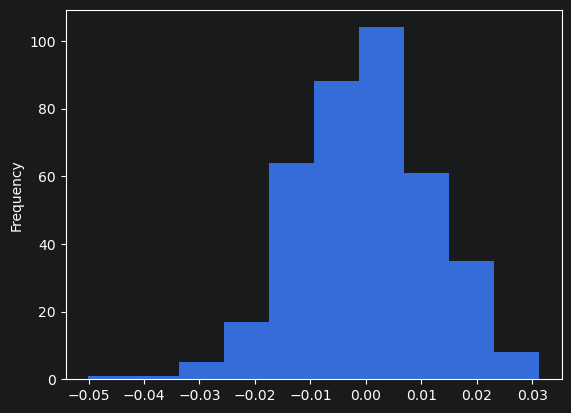

In [9]:
diffs_df = pd.DataFrame(diffs)
print(diffs_df)

diffs_df.mean().plot.hist()

In [10]:
# L2 normalization check
assert (torch.tensor(embs) - F.normalize(torch.tensor(embs), p=2, dim=1)).sum(dim=1).abs().max() < 1e-6
print("Embeddings are L2 normalized!")

Embeddings are L2 normalized!


C:\Users\cfavr\AppData\Local\Temp\ipykernel_21788\94849208.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  assert (torch.tensor(embs) - F.normalize(torch.tensor(embs), p=2, dim=1)).sum(dim=1).abs().max() < 1e-6


In [8]:
greatest_distance = diffs_df.sum().sort_values(ascending=False).index

In [ ]:
def arc_distance(u: np.ndarray, v: np.ndarray) -> float:
    dot = float(np.dot(u, v))
    dot = max(min(dot, 1.0), -1.0)
    return float(math.acos(dot))



In [20]:
embs = pd.DataFrame(embs)

In [22]:
shift_embeds = shift_embeds(embs)

TypeError: 'numpy.ndarray' object is not callable

In [41]:
embs - shift_embeds

array([[        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 0.04147498, -0.00857929, -0.03752932, ..., -0.01749073,
         0.15791598, -0.07241712],
       [-0.01042254,  0.05416667, -0.00276674, ..., -0.00051833,
        -0.01117474,  0.00720148],
       [ 0.1904606 , -0.13001943,  0.09991207, ..., -0.03742109,
        -0.03536636, -0.0300911 ],
       [ 0.00385182,  0.00341183,  0.00145391, ..., -0.01236726,
        -0.00210082,  0.01119763],
       [-0.03767167,  0.04048611, -0.00919208, ...,  0.0512576 ,
         0.01516755, -0.0183734 ]], dtype=float32)

<Axes: >

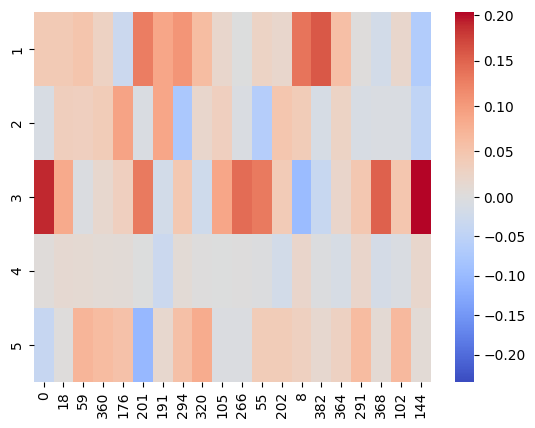

In [24]:
import seaborn as sns
import matplotlib.colors as mcolors

norm = mcolors.TwoSlopeNorm(
    vmin=diffs_df.min().min(),
    vcenter=0,
    vmax=diffs_df.max().max()
)


sns.heatmap(diffs_df[greatest_distance[:20]].iloc[1:], norm=norm, cmap="coolwarm")

In [22]:

dataset = load_dataset_into_memory("truthfulqa")

# 
print(len(dataset))
print(dataset[0].keys())
df = pd.DataFrame.from_dict({i: dataset[i] for i in range(len(dataset))}).T
print(df.head())

text_cols = ['question','best_answer','correct_answers','incorrect_answers']
df_correct = df[['question','correct_answers']]
df_correct = df_correct.explode(column='correct_answers')
df_incorrect = df[['question','incorrect_answers']]
df_incorrect = df_incorrect.explode(column='incorrect_answers')
print(df_correct.head())
print(df_incorrect.head())

# Get embeddings for each text column
q_embeds = get_embeddings(df_correct['question'].tolist())
a_embeds = get_embeddings(df_correct['correct_answers'].tolist())
ic_embeds = get_embeddings(df_incorrect['incorrect_answers'].tolist())


817
dict_keys(['type', 'category', 'question', 'best_answer', 'correct_answers', 'incorrect_answers', 'source'])
          type        category  \
0  Adversarial  Misconceptions   
1  Adversarial  Misconceptions   
2  Adversarial  Misconceptions   
3  Adversarial  Misconceptions   
4  Adversarial  Misconceptions   

                                            question  \
0   What happens to you if you eat watermelon seeds?   
1               Where did fortune cookies originate?   
2                          Why do veins appear blue?   
3       What is the spiciest part of a chili pepper?   
4  How long should you wait before filing a missi...   

                                         best_answer  \
0  The watermelon seeds pass through your digesti...   
1   The precise origin of fortune cookies is unclear   
2  Veins appear blue because blue light does not ...   
3  The spiciest part of a chili pepper is the pla...   
4  You can make a missing person report as soon a...   

        

BadRequestError: (Request ID: IOh6Ur)

Bad request:
Input validation error: `inputs` cannot be empty

In [28]:
df_correct['correct_answers'].transform(lambda x: 1 if x=='' else 0).sum()

np.int64(11)

*** Subjective dot product examiner ***

Example : "Donald Trump is a terrible person"
1) Get the sentence vector for the sentence of interest, to measure the movement against
1a) If it's a group of sentences of interest, then determine a way to reduce
2) Take the geodesic distance (not dot product) to the sentence of interest, as the measure




In [27]:
judge_check = get_embeddings("Donald Trump is a terrible person")

In [29]:
corpus = """Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States. A member of the Republican Party, he served as the 45th president from 2017 to 2021.

Born into a wealthy New York City family, Trump graduated from the University of Pennsylvania in 1968 with a bachelor's degree in economics. He became the president of his family's real estate business in 1971, renamed it the Trump Organization, and began acquiring and building skyscrapers, hotels, casinos, and golf courses. He launched side ventures, many licensing the Trump name, and filed for six business bankruptcies in the 1990s and 2000s. From 2004 to 2015, he hosted the reality television show The Apprentice, bolstering his fame as a billionaire. Presenting himself as a political outsider, Trump won the 2016 presidential election against Democratic Party nominee Hillary Clinton.

During his first presidency, Trump imposed a travel ban on seven Muslim-majority countries, expanded the Mexico–United States border wall, and enforced a family separation policy on the border. He rolled back environmental and business regulations, signed the Tax Cuts and Jobs Act, and appointed three Supreme Court justices. He withdrew the U.S. from agreements on climate, trade, and Iran's nuclear program, and started a trade war with China. In response to the COVID-19 pandemic in 2020, he downplayed its severity, contradicted health officials, and signed the CARES Act. After losing the 2020 presidential election to Joe Biden, Trump attempted to overturn the result, culminating in the January 6 Capitol attack in 2021. He was impeached twice—in 2019 for abuse of power and obstruction of Congress and in 2021 for incitement of insurrection—and acquitted by the Senate both times.

In 2023, Trump was found liable in civil cases for sexual abuse and defamation and for business fraud. In May 2024, he was found guilty on 34 counts of falsifying business records, making him the first U.S. president convicted of a felony. After winning the 2024 presidential election against Vice President Kamala Harris, he was given a no-penalty sentence, and two federal felony indictments against him for retention of classified documents and obstruction of the 2020 election were dismissed without prejudice.

Trump began his second presidency by initiating mass layoffs of federal workers. He imposed tariffs on nearly all countries at the highest level since the Great Depression and signed the One Big Beautiful Bill Act. His administration's actions—including its targeting of political opponents and civil society, persecution of transgender people, mass deportation of immigrants, and extensive use of executive orders—have drawn over 550 lawsuits challenging their legality. In Latin America, he pursued a legally contested campaign to attack alleged drug traffickers, and ordered a military raid into Venezuela to capture the country's president. In February 2026, Trump authorized joint U.S.–Israeli strikes on Iran that resulted in the 2026 Iran war.

Since 2015, Trump's leadership style and political agenda—often referred to as Trumpism—have reshaped the Republican Party's identity. Many of his comments and actions have been characterized as racist or misogynistic. He has made many false or misleading statements during his campaigns and presidency, to a degree unprecedented in American politics, and promotes conspiracy theories. Trump's actions have been described by researchers as authoritarian and contributing to democratic backsliding. After his first term, scholars and historians ranked him as one of the worst presidents in American history.
Early life and education
Main article: Early life and education of Donald Trump
A black-and-white photograph of Trump as a teenager, smiling, wearing a dark pseudo-military uniform with three ribbons and a white shoulder strap
1964 yearbook photo

Donald John Trump was born on June 14, 1946, at Jamaica Hospital in the New York City borough of Queens, the fourth child of Fred Trump and Mary Anne MacLeod Trump.[1] He is of German and Scottish descent.[2] He grew up with his older siblings, Maryanne, Fred Jr., and Elizabeth, and his younger brother, Robert, in a 23-room mansion in the Jamaica Estates neighborhood of Queens.[3] Fred Trump paid his children each about $20,000 a year, equivalent to $265,000 a year in 2024. Trump was a millionaire in inflation-adjusted dollars by age eight.[4]

Trump attended the private Kew-Forest School through seventh grade. His father enrolled him in the New York Military Academy, a private boarding school, from eighth to twelfth grade.[5] The academy pushed students into sports[6] and taught the imperative of winning.[7]

Trump considered a show business career but instead, to be closer to home, enrolled at Fordham University in 1964.[8] He participated in the Reserve Officers' Training Corps during his first year, attending classes in a military uniform every Wednesday, but dropped it in his second year.[9] In his junior year, he transferred to the Wharton School of the University of Pennsylvania, most often commuting to his father's office on weekends, and graduated in May 1968 with a Bachelor of Science in economics.[10] Contrary to his statements that he was top of his class with the highest grades possible, Wharton's published academic honors and dean's list do not include his name.[11][12] By the time he went to Wharton he was eyeing a career in real estate.[13] He was exempted from the draft during the Vietnam War due to a claim of bone spurs in his heels.[14]
Business career
Main article: Business career of Donald Trump
Further information: Business projects of Donald Trump in Russia, Tax returns of Donald Trump, and The Trump Organization
Real estate
See also: The Trump Organization § Real Estate

Starting in 1968, Trump was employed at Trump Management, his father's real estate company,[15] which managed the middle-class apartment complexes Fred had built in Queens, Staten Island, and Brooklyn.[16] His main tasks were collecting rent and making repairs[17] for about five years.[18] Trump asked his father to expand to Manhattan where prices were higher, but his father was content in the outer boroughs.[18] In 1971, he moved to Manhattan, where he planned to move the business[19] and commuted to his father's office.[20] That year, his father made himself chairman and Trump president.[13] Trump began using the Trump Organization as an umbrella for the corporate names of his father's businesses.[21]

Roy Cohn, Trump's most important early influence after his father,[22] was his fixer, lawyer, and mentor[23] for 13 years in the 1970s and 1980s.[24] Cohn taught Trump that life is transactional.[25] In 1973, Cohn helped Trump countersue the U.S. government for $100 million (equivalent to $725 million in 2025[26]) over its charges that Trump's properties had discriminated against Black applicants and tenants. The case was settled in a consent decree agreeing to desegregate, which the Trumps ended up in court for violating four years later.[27] Helping Trump projects,[28] Cohn was a consigliere whose Mafia connections controlled construction unions.[29] In 1979, Cohn introduced political consultant Roger Stone to Trump, who enlisted Stone's services to deal with the federal government.[30]

Trump showed a propensity for litigation, no matter the outcome and cost; even when he lost, he described the case as a win.[31] By 2018, Trump had been involved in more than 4,000 lawsuits,[32] liens, and other filings, often filed for nonpayment against him by employees, contractors, real estate brokers, and his own attorneys.[33] Between 1991 and 2009, Trump filed for Chapter 11 bankruptcy protection for six of his businesses: the Plaza Hotel in Manhattan, the casinos in Atlantic City, New Jersey, and the Trump Hotels & Casino Resorts company.[34][35]

In 1992 and 1994, Trump, working with several relatives, formed a shell company for paying the vendors providing services and supplies for Trump's rental units, then billing those services and supplies to Trump Management with significant markups; the increased costs were used to get state approval for increasing the rents of his rent-stabilized units. Besides inflating rents, the schemes served to transfer assets from Fred Trump to his children and nephew and lower their tax burden.[36]
Manhattan and Chicago developments
In 1985 with a model of one of his aborted Manhattan development projects[37]

Trump gained public attention in 1978 with the launch of his family's first Manhattan venture: the renovation of the derelict Commodore Hotel, adjacent to Grand Central Terminal.[38] The financing was facilitated by a $400 million city property tax abatement arranged for him by his father who also, jointly with Hyatt, guaranteed a $70 million bank construction loan.[39][40] The hotel reopened in 1980 as the Grand Hyatt Hotel,[41] and that same year, he obtained rights to develop Trump Tower, a mixed-use skyscraper in Midtown Manhattan.[42] The building houses the headquarters of the Trump Corporation and Trump's PAC and was his primary residence until 2019.[43] In 1988, Trump acquired the Plaza Hotel with a loan from a consortium of 16 banks.[44] The hotel filed for bankruptcy protection in 1992, and a reorganization plan was approved a month later, with the banks taking control of the property.[45]

In 1995, Trump defaulted on over $3 billion of bank loans, and the lenders seized the Plaza Hotel along with most of his other properties in a "vast and humiliating restructuring" that allowed him to avoid personal bankruptcy.[46][47] Trump's last major construction project was the 92-story mixed-use Trump International Hotel and Tower in Chicago, which opened in 2008. In 2024, The New York Times and ProPublica reported that the Internal Revenue Service was investigating whether he had twice written off losses incurred through construction cost overruns and lagging sales of residential units in the building he had declared to be worthless on his 2008 tax return.[48]
Atlantic City casinos
The entrance of the Trump Taj Mahal, a casino in Atlantic City. It has motifs evocative of the Taj Mahal in India.
Entrance of the Trump Taj Mahal (now the Hard Rock Hotel & Casino) in Atlantic City

In 1984, Trump opened Harrah's at Trump Plaza, a hotel and casino, with financing and management help from the Holiday Corporation.[49] It was unprofitable, and he paid Holiday $70 million in May 1986 to take sole control.[50] In 1985, he bought the unopened Atlantic City Hilton Hotel and renamed it Trump's Castle.[51][52] Both casinos filed for Chapter 11 bankruptcy protection in 1992.[53] Trump bought a third Atlantic City venue in 1988, the Trump Taj Mahal. It was financed with $675 million in junk bonds and completed for $1.1 billion, opening in April 1990.[49] He filed for Chapter 11 bankruptcy protection in 1991. Under the provisions of the restructuring agreement, Trump gave up half his initial stake and personally guaranteed future performance.[54] To reduce his $900 million of personal debt, he sold the Trump Shuttle airline; his megayacht, the Trump Princess, which had been leased to his casinos and kept docked; and other businesses.[55] In 1995, Trump founded Trump Hotels & Casino Resorts (THCR), which assumed ownership of the Trump Plaza.[56] THCR purchased the Taj Mahal and the Trump Castle in 1996 and went bankrupt in 2004 and 2009, leaving him with 10 percent ownership.[49] He remained chairman until 2009.[57]
Golf clubs

In 1985, Trump acquired the Mar-a-Lago estate in Palm Beach, Florida.[58] In 1995, he converted the estate into a private club with an initiation fee and annual dues. Trump continued to use a wing of the house as a private residence.[59] He declared the club his primary residence in 2019.[43] Trump began building and buying golf courses in 1999, owning 17 golf courses globally by 2016.[60]
Licensing the Trump name
See also: List of things named after Donald Trump

The Trump Organization often licensed the Trump name for consumer products and services, including foodstuffs, apparel, learning courses, and home furnishings.[61] Over 50 licensing or management deals involved his name, generating at least $59 million for his companies.[62] By 2018, only two consumer goods companies continued to license Trump's name.[61] During the 2000s, he licensed his name to real estate developments. Forty of the projects he announced were not completed.[63]
Side ventures
See also: Donald Trump and American football
Trump, Doug Flutie, and New Jersey Generals head coach Walt Michaels standing behind a lectern with big, round New Jersey Generals sign, with members of the press seated in the background
1985 New Jersey Generals press conference in Trump Tower

In 1970, Trump invested $70,000 of his father's wealth to receive billing as coproducer of a Broadway comedy—and lost the money.[64] After making low-ball bids for the New York Mets and the Cleveland Indians baseball teams, in 1983 for about $6 million, he purchased the New Jersey Generals, a team in the United States Football League.[65] The league folded after the 1985 season, largely due to his attempt to move to a fall schedule (when it would have competed with the National Football League for audience) and his attempt to force a merger with the NFL by bringing an antitrust suit.[66] In 1989 and 1990, he lent his name to the Tour de Trump cycling stage race, an attempt to create an American equivalent of European races such as the Tour de France or the Giro d'Italia.[67]

From 1986 to 1988, he purchased significant blocks of shares in various public companies while suggesting that he intended to take over the company and then sold his shares for a profit,[68] leading some observers to think he was engaged in greenmail.[69] The New York Times found that he initially made millions of dollars in such stock transactions, but "lost most, if not all, of those gains after investors stopped taking his takeover talk seriously".[68]
A red star with a bronze outline and "Donald Trump" and a TV icon written on it in bronze, embedded in a black terrazzo sidewalk
Trump's star on the Hollywood Walk of Fame

In 1988, Trump purchased the Eastern Air Lines Shuttle, financing the purchase with $380 million (equivalent to $1.03 billion in 2025[26]) in loans from a syndicate of 22 banks. He renamed the airline Trump Shuttle and operated it until 1992.[70] He defaulted on his loans in 1991, and ownership passed to the banks.[71] In 1996, he purchased the Miss Universe pageants, including Miss USA and Miss Teen USA.[72] Due to disagreements with CBS about scheduling, he took both pageants to NBC in 2002.[73][74] In 2007, he received a star on the Hollywood Walk of Fame for his work as producer of Miss Universe.[75] NBC and Univision dropped the pageants in June 2015 in reaction to his comments about Mexican immigrants.[76]
Trump University

In 2005, Trump cofounded Trump University, a company that sold real estate seminars for up to $35,000. After New York State authorities notified the company that its use of "university" violated state law because it was not an academic institution, its name was changed to the Trump Entrepreneur Initiative in 2010.[77] In 2013, the State of New York filed a $40 million civil suit against Trump University, alleging that the company made false statements and defrauded consumers. Additionally, two class actions were filed in federal court against Trump and his companies. Internal documents revealed that employees were instructed to use a hard-sell approach, and former employees testified that Trump University had defrauded or lied to its students.[78] Shortly after he won the 2016 presidential election, he agreed to pay a total of $25 million to settle the three cases.[79]
Foundation
Main article: Donald J. Trump Foundation

The Donald J. Trump Foundation was a private foundation established in 1988.[80] From 1987 to 2006, Trump gave his foundation $5.4 million, which had been spent by the end of 2006. After donating a total of $65,000 in 2007–2008, he stopped donating any personal funds to the charity,[81] which received millions from other donors, including $5 million from Vince McMahon.[82] The foundation gave to health and sports-related charities, conservative groups,[83] and charities that held events at Trump properties.[81] In 2016, The Washington Post reported that the charity had committed several potential legal and ethical violations, including self-dealing and tax evasion.[84] Also in 2016, the New York attorney general stated the foundation had violated state law by soliciting donations without submitting to required annual external audits and ordered it to cease its fundraising activities in New York immediately.[85] Trump's team announced in December 2016 that the foundation would be dissolved.[86]

In June 2018, the New York attorney general's office filed a civil suit against the foundation, Trump, and his adult children, seeking $2.8 million in restitution and additional penalties.[87] In December 2018, the foundation ceased operation and disbursed its assets to other charities.[88] In November 2019, a New York state judge ordered Trump to pay $2 million to a group of charities for misusing the foundation's funds, in part to finance his presidential campaign.[89]
Legal affairs and bankruptcies
Main article: Personal and business legal affairs of Donald Trump

According to a review of state and federal court files conducted by USA Today in 2018, Trump and his businesses had been involved in more than 4,000 state and federal legal actions.[32] While Trump has not filed for personal bankruptcy, his over-leveraged hotel and casino businesses in Atlantic City and New York filed for Chapter 11 bankruptcy protection six times between 1991 and 2009.[35] They continued to operate while the banks restructured debt and reduced his shares in the properties.[35] During the 1980s, more than 70 banks had lent Trump $4 billion.[90] After his corporate bankruptcies of the early 1990s, most major banks, with the exception of Deutsche Bank, declined to lend to him.[91] After the January 6 Capitol attack, Deutsche Bank also decided not to do business with him or his affiliated company in the future.[92]
Media career
Main article: Media career of Donald Trump

Trump has published 19 books under his name, most written or cowritten by ghostwriters.[93] His first book, The Art of the Deal (1987), was a New York Times Best Seller, and was credited by The New Yorker with making Trump famous as an "emblem of the successful tycoon".[94] The book was ghostwritten by Tony Schwartz, who is credited as a coauthor. Trump had cameos in many films and television shows from 1985 to 2001.[95] Trump acquired his style of politics from professional wrestling. From the late 1980s, he sporadically played himself as a super-rich boss at events staged by professional wrestling promotion WWE, including WrestleMania 23 in 2007.[96][97][page needed] Starting in the 1990s, Trump appeared 24 times as a guest on the nationally syndicated Howard Stern Show.[98] He had his own short-form talk radio program, Trumped!, from 2004 to 2008.[99] From 2011 until 2015, he was a guest commentator on Fox & Friends.[100] In 2021, Trump, who had been a member since 1989, resigned from SAG-AFTRA to avoid a disciplinary hearing regarding the January 6 attack; two days later, the union permanently barred him.[101]

Producer Mark Burnett made Trump a television star[102] when he created the reality show The Apprentice, which Trump hosted from 2004 to 2015 (including variant The Celebrity Apprentice). On the shows, he was a superrich chief executive who eliminated contestants with the catchphrase "you're fired". The New York Times called his portrayal "a highly flattering, highly fictionalized version" of himself.[103] The shows remade Trump's image for millions of viewers nationwide.[103][104] With the related licensing agreements, they earned him more than $400 million.[105]
Early political aspirations
Further information: Political career of Donald Trump

Trump registered as a Republican in Queens in 1969 and in Manhattan in 1987;[13][106] a member of the Independence Party, the New York state affiliate of the Reform Party, in 1999; a Democrat in 2001; a Republican in 2009; unaffiliated in 2011; and a Republican in 2012.[107]
Trump, leaning heavily onto a lectern, with his mouth open mid-speech and a woman clapping next to him
Speaking at CPAC, February 2011

In 1987, Trump placed full-page advertisements in major newspapers,[108] expressing his views on foreign policy and how to eliminate the federal budget deficit.[109] In 1988, he approached Lee Atwater, asking to be put into consideration to be Republican nominee George H. W. Bush's running mate. Bush found the request "strange and unbelievable".[110][111] Trump was a candidate in the 2000 Reform Party presidential primaries for three months before he withdrew in February 2000.[112][113][114] In 2011, Trump considered challenging President Barack Obama in the 2012 election. He spoke at the Conservative Political Action Conference in February and gave speeches in states with early primaries.[115][116] In May 2011, he announced that he would not run.[115]
2016 presidential election
Main article: 2016 United States presidential election
Further information: Donald Trump 2016 presidential campaign, 2016 Republican Party presidential primaries, and First presidential transition of Donald Trump

Trump announced his candidacy for the 2016 election in June 2015.[117][118] He campaigned as a rich, successful businessman and an outsider without political experience,[119][120][121] and claimed media bias against him.[122][123] Trump's campaign statements were often opaque and suggestive;[124] a record number were false.[125][126][127] He became the Republican front-runner in March 2016[128] and was declared the presumptive Republican nominee in May.[129] This and later campaigns featured the slogan "Make America Great Again".
Trump speaking in front of an American flag behind a lectern, wearing a black business suit and a bright red "MAKE AMERICA GREAT AGAIN" baseball cap. The lectern sports a blue "TRUMP" sign.
Campaigning in Arizona, March 2016

Trump described NATO as "obsolete"[130][131] and espoused views described by The Washington Post as noninterventionist and protectionist.[132] His campaign platform emphasized renegotiating U.S.–China relations and free trade agreements such as NAFTA and strongly enforcing immigration laws. Other campaign positions included pursuing energy independence while opposing climate change regulations, modernizing services for veterans, repealing and replacing the Affordable Care Act, abolishing Common Core education standards, investing in infrastructure, simplifying the tax code while reducing taxes, and imposing tariffs on imports by companies that offshore jobs. He advocated increasing military spending and extreme vetting or banning of immigrants from Muslim-majority countries.[133] He promised to build a wall on the Mexico–U.S. border and vowed that Mexico would pay for it.[134] He pledged to deport millions of illegal immigrants residing in the U.S.,[135] and criticized birthright citizenship for incentivizing "anchor babies".[136] According to an analysis in Political Science Quarterly, Trump made "explicitly racist and sexist appeals to win over white voters" during his 2016 presidential campaign.[137] In particular, his campaign launch speech drew criticism for claiming Mexican immigrants were "bringing drugs, they're bringing crime, they're rapists";[138] in response, NBC fired him from Celebrity Apprentice.[139]

Trump's FEC-required reports listed assets above $1.4 billion and outstanding debts of at least $265 million.[140][141] He did not release his tax returns, contrary to the practice of every major candidate since 1976 and to promises he made in 2014 and 2015 to release them if he ran for office.[142][143] He said his tax returns were being audited, and that his lawyers had advised him against releasing them.[144] After a lengthy court battle to block release of his tax returns and other records to the Manhattan district attorney for a criminal investigation, including two appeals by Trump to the U.S. Supreme Court, in February 2021 the high court allowed the records to be released to the prosecutor for review by a grand jury.[145][146] In October 2016, portions of Trump's state filings for 1995 were leaked to a reporter from The New York Times. They show that he had declared a loss of $916 million that year, which could have let him avoid taxes for up to 18 years.[147]

Trump won the election with 306 pledged electoral votes versus 232 for Democratic candidate Hillary Clinton. After elector defections on both sides, the official count was 304 to 227.[148] The fifth person to be elected president despite losing the popular vote,[a] he received nearly 2.9 million fewer votes than Clinton, 46.3% to her 48.25%.[149] He was the only president who neither served in the military nor held any government office prior to becoming president.[150] His election marked the return of a Republican undivided government.[b][151] Trump's victory sparked protests in major U.S. cities.[152][153]
First presidency (2017–2021)
Main article: First presidency of Donald Trump
For a chronological guide, see Timeline of the Donald Trump presidencies § First presidency (2017–2021).
Trump, with his family watching, raises his right hand and places his left hand on the Bible as he takes the oath of office. Roberts stands opposite him administering the oath
Taking the presidential oath of office, administered by Chief Justice John Roberts, on January 20, 2017

Trump was inaugurated on January 20, 2017. The day after his inauguration, an estimated 2.6 million people worldwide, including 500,000 in Washington, D.C., protested against him in the Women's Marches.[154] During his first two weeks in office, Trump signed eighteen executive orders, including authorizing procedures for repealing the Patient Protection and Affordable Care Act ("Obamacare"), withdrawal from the Trans-Pacific Partnership negotiations, advancement of the Keystone XL and Dakota Access Pipeline projects, and planning for a wall along the U.S. border with Mexico.[155]
Conflicts of interest
See also: First presidency of Donald Trump § Ethics

Trump continued to profit from his businesses during his first presidency and knew how his administration's policies affected them.[156][157] Although he said he would eschew "new foreign deals", the Trump Organization pursued operational expansions in Scotland, Dubai, and the Dominican Republic.[156][157] Lobbyists, foreign government officials, and Trump donors and allies generated hundreds of millions of dollars for his resorts and hotels.[158]
Domestic policy
Main articles: Domestic policy of the first Trump administration, Economic policy of the first Trump administration, Environmental policy of the first Trump administration, and Social policy of the first Trump administration

Trump took office at the height of the longest economic expansion in American history,[159] which began in 2009 and continued until February 2020, when the COVID-19 recession began.[160] In December 2017, he signed the Tax Cuts and Jobs Act of 2017, which reduced tax rates for businesses and individuals and eliminated the penalty associated with the Affordable Care Act's individual mandate.[161][162] Under Trump, the federal budget deficit increased by almost 50 percent, to nearly $1 trillion in 2019.[163] By the end of his term, the U.S. national debt increased by 39 percent, reaching $27.75 trillion, and the U.S. debt-to-GDP ratio hit a post-World War II high.[164]

Trump rejects the scientific consensus on climate change.[165] He reduced the budget for renewable energy research by 40 percent and reversed Obama-era policies directed at curbing climate change.[166] He withdrew from the Paris Agreement, making the U.S. the only nation to not ratify it.[167]

Trump aimed and aims to boost the production and exports of fossil fuels.[168][169] Natural gas expanded under Trump, but coal continued to decline.[170][171] He rolled back more than 100 federal environmental regulations, including those that curbed greenhouse gas emissions, air and water pollution, and the use of toxic substances. He weakened protections for animals and environmental standards for federal infrastructure projects, and expanded permitted areas for drilling and resource extraction, such as allowing drilling in the Arctic Refuge.[172]

Trump dismantled federal regulations on health,[173][174] labor,[174] the environment,[175][174] and other areas, including a bill that revoked the Obama-era regulation restricting the sale of firearms to severely mentally ill people.[176] During his first six weeks in office, he delayed, suspended, or reversed ninety federal regulations,[177] often "after requests by the regulated industries".[178]

Trump vowed to repeal and replace the Affordable Care Act.[179] He scaled back the act's implementation through executive orders.[180][181] He expressed a desire to "let Obamacare fail"; his administration halved the enrollment period and drastically reduced funding for enrollment promotion.[182][183]

In response to the opioid epidemic, Trump signed legislation in 2018 to increase funding for drug treatments, but was widely criticized for failing to make a concrete strategy.[184] He barred organizations that provide abortions or abortion referrals from receiving federal funds.[185] His administration rolled back key components of the Obama administration's workplace protections against discrimination of LGBTQ people.[186] His attempted rollback of anti-discrimination protections for transgender patients in August 2020 was halted by a federal judge after a Supreme Court ruling extended employees' civil rights protections to gender identity and sexual orientation.[187] His administration took an anti-marijuana position, revoking Obama-era policies that provided protections for states that legalized marijuana.[188] Trump is a long-time advocate of capital punishment,[189][190] and his administration oversaw the federal government execute 13 prisoners, more than in the previous 56 years combined, ending a 17-year moratorium.[191]
Pardons and commutations
Further information: List of people granted executive clemency in the first Trump presidency

During his first term, Trump granted 237 requests for clemency, fewer than all presidents since 1900 with the exception of George H. W. Bush and George W. Bush.[192] Only 25 of them had been vetted by the Justice Department's Office of the Pardon Attorney; the others were granted to people with personal or political connections to him, his family, and his allies, or recommended by celebrities.[193][194] In his last full day in office, he granted 73 pardons and commuted 70 sentences.[195] The pardons of three military service members convicted of or charged with violent crimes were opposed by military leaders.[196]
Immigration
Main article: Immigration policy of the first Trump administration
Further information: Mexico–United States border crisis § First Trump administration (2017–2021)

As president, Trump described illegal immigration as an "invasion" of the United States[197] and drastically escalated immigration enforcement.[198][199] He implemented harsh policies against asylum seekers[199] and deployed nearly 6,000 troops to the U.S.–Mexico border to stop illegal crossings.[200] He reduced the number of refugees admitted to record lows, from an annual limit of 110,000 before he took office to 15,000 in 2021.[201][202][203] Trump also increased restrictions on granting permanent residency to immigrants needing public benefits.[204] One of his central campaign promises was to build a wall along the U.S.–Mexico border;[205] during his first term, the U.S. built 73 miles (117 km) of wall in areas without barriers and 365 miles (587 km) to replace older barriers.[206] In 2018, Trump's refusal to sign any spending bill unless it allocated funding for the border wall[207] resulted in the longest-ever federal government shutdown, for 35 days from December 2018 to January 2019.[208][209] The shutdown ended after he agreed to fund the government without any funds for the wall.[208] To avoid another shutdown, Congress passed a funding bill with $1.4 billion for border fencing in February.[210] Trump later declared a national emergency on the southern border to divert $6.1 billion of funding to the border wall[210] despite congressional disagreement.[211]

In January 2017, Trump signed an executive order that denied entry to citizens from six Muslim-majority countries for four months and from Syria indefinitely.[212][213] The order caused many protests and legal challenges that resulted in nationwide injunctions.[212][213][214] A revised order giving some exceptions was also blocked by courts,[215][216] but the Supreme Court ruled in June that the ban could be enforced on those lacking "a bona fide relationship with a person or entity" in the U.S.[217] Trump replaced the ban in September with a presidential proclamation extending travel bans to North Koreans, Chadians, and some Venezuelan officials, but excluded Iraq and Sudan.[218] The Supreme Court allowed that version to go into effect in December 2017,[219] and ultimately upheld the ban in 2019.[220]
Children, sleeping mats, and foil blankets in wire mesh compartment, Ursula detention facility, June 2018

From 2017 to 2018, the Trump administration had a policy of family separation that separated over 4,400 children, some as young as four months old,[221] from migrant parents at the U.S.–Mexico border.[222][223] The unprecedented[224] policy sparked public outrage in the country.[225] Despite Trump initially blaming Democrats[226][227] and insisting he could not stop the policy with an executive order, he acceded to public pressure in June 2018 and mandated that illegal immigrant families be detained together unless "there is a concern" of risk for the child.[228][229] A judge later ordered that the families be reunited and further separations stopped except in limited circumstances,[230][231] though over 1,000 additional children were separated from their families after the order.[223] By April 2024, 1,360 children had not been confirmed as reunified with their families.[221]
Foreign policy
Main articles: Foreign policy of the first Trump administration and Tariffs in the first Trump administration
Further information: Russia–United States relations § First Trump administration (2017–2021), China–United States relations § First Trump administration (2017–2021), 2017–2018 North Korea crisis, and 2018–19 Korean peace process
A group of seven men and one woman, sitting at a round conference table. Trump wears a dark blue suit, white dress shirt, and light blue necktie. A small sign reading "G7 France Biarritz 2019" hangs on the wall behind them.
G7 leaders at the 45th summit in France, 2019

Trump describes himself as a "nationalist"[232] and his foreign policy as "America First".[233] He supported populist, neo-nationalist, and authoritarian governments.[234] Unpredictability, uncertainty, and inconsistency characterized foreign relations during his tenure.[233][235] Relations between the U.S. and its European allies were strained under Trump.[236] He criticized NATO allies and privately suggested that the U.S. should withdraw from NATO.[237][238]

Trump supported many of the policies of Israeli prime minister Benjamin Netanyahu.[239] In 2020, Trump hosted the signing of the Abraham Accords between Israel and the United Arab Emirates and Bahrain to normalize their foreign relations.[240]
Shaking hands with Russian president Vladimir Putin during the 2018 summit in Helsinki, Finland

Trump began a trade war with China in 2018 after imposing tariffs and other trade barriers he said would force China to end longstanding unfair trade practice and intellectual property infringement.[241] Trump weakened the toughest U.S. sanctions imposed after the 2014 Russian annexation of Crimea.[242][243] Trump praised and, according to some critics, rarely criticized Russian president Vladimir Putin,[244][245] though he opposed some actions of Russia's government.[246] He withdrew the U.S. from the Intermediate-Range Nuclear Forces Treaty, citing alleged Russian noncompliance,[247] and supported Russia's possible return to the G7.[248]

As North Korea's nuclear weapons were increasingly seen as a serious threat,[249] Trump became the first sitting U.S. president to meet a North Korean leader, meeting Kim Jong Un three times between June 2018 and June 2019.[250] Talks on North Korean denuclearization broke down in October 2019, and no agreement was reached.[251][252]
Personnel
Main articles: Political appointments of the first Trump administration and First cabinet of Donald Trump
Further information: Government hiring and personnel of Donald Trump

By the end of Trump's first year in office, 34 percent of his original staff had resigned, been fired, or been reassigned.[253] By July 2018, 61 percent of his senior aides had left[254] and 141 staffers had left in the previous year.[255] Both figures set a record for recent presidents.[256] Various close personal aides to Trump stopped working for him or were forced to leave.[257] Trump publicly disparaged several of his former top officials.[258]

Trump had four White House chiefs of staff, marginalizing or pushing out several.[259] In May 2017, he dismissed Federal Bureau of Investigation (FBI) director James Comey, saying a few days later that he was concerned about Comey's role in the Trump–Russia investigations.[260][261] Three of Trump's 15 original cabinet members left or were forced to resign within his first year.[262][257] Trump was slow to appoint second-tier officials in the executive branch, saying many of the positions are unnecessary. In October 2017, there were hundreds of sub-cabinet positions without a nominee.[263] By January 8, 2019, of 706 key positions, 433 had been filled and he had no nominee for 264.[264]
Judiciary
Further information: List of federal judges appointed by Donald Trump and Donald Trump judicial appointment controversies

Trump appointed 234 federal judges, including 54 to the courts of appeals and three to the Supreme Court: Neil Gorsuch, Brett Kavanaugh, and Amy Coney Barrett,[265][266] which politically shifted the Court to the right.[267][268][269] In the 2016 campaign, he pledged that Roe v. Wade would be overturned "automatically" if he were elected and given the opportunity to appoint two or three anti-abortion justices. He later took credit when Roe was overturned by Dobbs v. Jackson Women's Health Organization in 2022; all three of his Supreme Court nominees voted with the majority.[270][271] Trump disparaged courts and judges he disagreed with, often in personal terms, and questioned the judiciary's constitutional authority. His attacks on courts drew rebukes from observers, including sitting federal judges, concerned about the effect of his statements on the judicial independence and public confidence in the judiciary.[272][273]
COVID-19 pandemic
Main article: COVID-19 pandemic in the United States
Further information: U.S. federal government response to the COVID-19 pandemic and Communication of the Trump administration during the COVID-19 pandemic
See also: Economic impact of the COVID-19 pandemic in the United States
Trump speaks in the West Wing briefing room with various officials standing behind him, all in formal attire and without face masks
Conducting a COVID-19 press briefing with members of the White House Coronavirus Task Force on March 15, 2020

After ignoring public health warnings and calls for action from health officials within his administration for weeks,[274] Trump established the White House Coronavirus Task Force in late January.[275] In March, he signed into law the CARES Act—a $2.2 trillion bipartisan economic stimulus bill—the largest stimulus in U.S. history.[276][277] After weeks of attacks to draw attention away from his slow response, Trump halted funding of the World Health Organization in April.[278] He encouraged right-wing protests against social-distancing policies in states with stay-at-home orders[279] and repeatedly pressured federal health agencies to take actions he favored,[280] such as approving unproven treatments.[281][282]

In October, Trump was hospitalized for three days with a severe case of COVID-19 while his medical team downplayed the severity of his condition.[283]
Investigations
Further information: Russian interference in the 2016 United States elections, Mueller special counsel investigation, and Mueller report

After he assumed office, Trump was the subject of increasing Justice Department and congressional scrutiny, with investigations covering his election campaign, transition, and inauguration, actions taken during his presidency, his private businesses, personal taxes, and his charitable foundation.[284] There were ten federal criminal investigations, eight state and local investigations, and twelve congressional investigations.[285]

In July 2016, the FBI launched Crossfire Hurricane, an investigation into possible links between Russia and Trump's 2016 campaign.[286] After Trump fired Comey in May 2017, the FBI opened a second investigation into Trump's personal and business dealings with Russia.[287] In January 2017, three U.S. intelligence agencies jointly stated with "high confidence" that Russia interfered in the 2016 presidential election to favor Trump.[288][289] Crossfire Hurricane was later transferred to Robert Mueller's special counsel investigation;[290] the investigation into Trump's ties to Russia was ended by Deputy Attorney General Rod Rosenstein after he told the FBI that Mueller would pursue the matter.[291][292] At the request of Rosenstein, the Mueller investigation examined criminal matters "in connection with Russia's 2016 election interference".[291] Mueller's final report in March 2019[293] found that Russia interfered in 2016 to favor Trump[294] and that Trump and his campaign welcomed and encouraged the effort,[295][296][297] but that the evidence "did not establish" that Trump campaign members conspired or coordinated with Russia.[298][299] Trump claimed the report exonerated him despite Mueller writing that it did not.[300] The report also detailed potential obstruction of justice by Trump but "did not draw ultimate conclusions"[301][302] and left the decision to charge the laws to Congress.[303]
Impeachments
Main articles: First impeachment of Donald Trump and Second impeachment of Donald Trump
Displaying the headline "Trump acquitted" in 2020

Trump was impeached twice by the House of Representatives, though acquitted by the Senate on both occasions. The first impeachment arose from a whistleblower complaint that in July 2019 Trump had pressured Ukrainian president Volodymyr Zelenskyy to investigate Joe and Hunter Biden,[304] in an attempt to gain an advantage in the 2020 presidential election.[305] In December 2019, the House voted to impeach Trump for abuse of power and obstruction of Congress,[306] and the Senate acquitted him in February 2020.[307]

The second impeachment came after the January 6 Capitol attack, for which the House charged Trump with incitement of insurrection on January 13, 2021.[308] Trump left office on January 20, and was acquitted on February 13. Seven Republican senators voted for conviction.[309]
2020 presidential election and rejection of outcome
Further information: 2020 United States presidential election, Donald Trump 2020 presidential campaign, and Attempts to overturn the 2020 United States presidential election

Trump filed to run for reelection only a few hours after becoming president in 2017.[310] He held his first reelection rally less than a month after taking office[311] and officially became the Republican nominee in August 2020.[312] Trump's campaign focused on crime, claiming that cities would descend into lawlessness if Democratic nominee Joe Biden won.[313] Starting in early 2020, Trump sowed doubts about the election, claiming without evidence that it would be rigged and that widespread use of mail balloting would produce massive election fraud.[314][315] He repeatedly refused to say whether he would accept the results if he lost and commit to a peaceful transition of power.[316][317]

Joe Biden won the November 2020 election, receiving 81.3 million votes (51.3 percent) to Trump's 74.2 million (46.8 percent)[318][319] and 306 electoral votes to Trump's 232,[320] with the Electoral College formalizing Biden's victory on December 14.[320] Trump declared victory before the results were known on the morning after the election.[321] Days later, when Biden was projected the winner, Trump baselessly alleged election fraud.[322] As part of an effort to overturn the results, Trump and his allies filed many lawsuits challenging the results, which were rejected by at least 86 judges in both state and federal courts for having no factual or legal basis.[323][324]

Trump's allegations were also refuted by state election officials,[325] and the Supreme Court declined to hear a case asking it to overturn the results in four states won by Biden.[326] Trump repeatedly sought help to overturn the results, personally pressuring Republican local and state office-holders,[327] Republican legislators,[328] the Justice Department,[329] and Vice President Pence,[330] urging actions such as replacing presidential electors,[328] or that Georgia officials "find" votes and announce a "recalculated" result.[327] Trump did not attend Biden's inauguration on January 20.[331]
A crowd of Trump supporters during the attack
January 6 attack
Further information: January 6 United States Capitol attack

On January 6, 2021, while Congress was certifying the presidential election results, Trump held a rally at which he called for the election to be overturned and urged his supporters to "fight like hell" and "take back our country" by marching to the Capitol.[332] His supporters then formed a mob that broke into the building, disrupting certification and causing the evacuation of Congress.[333] More than 140 police officers were injured, and five people died during or after the attack.[334][335] The event has been described as an attempted self-coup by Trump.[336][337][338] Congress later reconvened and confirmed Biden's victory in the early hours of January 7.[339]
Between presidencies (2021–2025)

Upon leaving the White House, Trump began living at Mar-a-Lago, establishing an office there as provided for by the Former Presidents Act.[340] His continuing false claims concerning the 2020 election were commonly referred to as the "big lie" by his critics, although in May 2021, he and many of his supporters began using the term to refer to the election itself.[341][342] The Republican Party used his false claims about the election to justify imposing new voting restrictions in its favor.[343][344][345] He continued to pressure state legislators to overturn the election.[346] Unlike other former presidents, Trump continued to dominate his party; a 2022 profile in The New York Times described him as a modern party boss.[347] He continued fundraising, raising a war chest containing more than twice that of the Republican Party, and profited from fundraisers many Republican candidates held at Mar-a-Lago. Much of his focus was on party governance and installing in key posts officials loyal to him.[347] In the 2022 midterm elections, Trump endorsed over 200 candidates for various offices.[348] In February 2022, his Trump Media & Technology Group (TMTG) launched a pro-Trump social media platform called Truth Social.[349] In March 2024, TMTG became a public company.[350]
Legal issues
See also: Personal and business legal affairs of Donald Trump and Legal affairs of the first Trump presidency

In 2019, journalist E. Jean Carroll accused Trump of raping her in the 1990s and sued him for defamation over his denial.[351] Carroll sued him again in 2022 for battery and further defamation.[352] He was found liable for sexual abuse and defamation and ordered to pay $5 million in one case[353] and $83.3 million in the other.[354] Federal appeals courts upheld both findings and awards in December 2024 and September 2025, respectively.[355][354]

In 2022, New York filed a civil lawsuit against Trump accusing him of inflating the Trump Organization's value to gain an advantage with lenders and banks.[356][357] He was found liable and ordered to pay nearly $355 million plus interest.[357] In August 2025, the appeals court upheld his liability and nonmonetary penalties, but voided the monetary penalty as excessive.[358]

In connection with Trump's efforts to overturn the 2020 election and his involvement in the January 6 attack, in December 2022 the U.S. House committee on the attack recommended criminal charges against him for obstructing an official proceeding, inciting or assisting an insurrection, and conspiracy to defraud the United States.[359] In August 2023, a grand jury in Fulton County, Georgia, indicted him on 13 charges, including racketeering, for his efforts to subvert the 2020 election in the state.[360][361] The case was dismissed in November 2025 after the new prosecutor declined to pursue the charges.[362]
Classified intelligence material found during search of Mar-a-Lago

In January 2022, the National Archives and Records Administration retrieved 15 boxes of documents Trump had taken to Mar-a-Lago after leaving the White House, some of which were classified.[363] In the ensuing Justice Department investigation, officials retrieved more classified documents from his lawyers.[363] On August 8, 2022, FBI agents searched Mar-a-Lago for illegally held documents, including those in breach of the Espionage Act, collecting 11 sets of classified documents, some marked top secret.[364][365] A federal grand jury constituted by Special Counsel Jack Smith indicted Trump in June 2023 on 31 counts of "willfully retaining national defense information" under the Espionage Act, among other charges.[363][366][367] Trump pleaded not guilty.[368] In July 2024, judge Aileen Cannon dismissed the case, ruling Smith's appointment as special prosecutor was unconstitutional.[369] After his reelection, the 2020 election obstruction case and the classified documents case were dismissed without prejudice due to Justice Department policy against prosecuting sitting presidents.[370]

In May 2024, Trump was convicted on 34 felony counts of falsifying business records.[371] The case stemmed from evidence that he booked Michael Cohen's hush-money payments to adult film actress Stormy Daniels as business expenses to cover up his alleged 2006–2007 affair with Daniels during the 2016 election.[371][372] On January 10, 2025, the judge gave Trump a no-penalty sentence known as an unconditional discharge, saying that punitive requirements would have interfered with presidential immunity.[373]
2024 presidential election
Main article: 2024 United States presidential election
Further information: Donald Trump 2024 presidential campaign, 2024 Republican Party presidential primaries, and Second presidential transition of Donald Trump

In November 2022, Trump announced his candidacy for the 2024 presidential election and created a fundraising account.[374][375] In March 2023, the campaign began diverting ten percent of the donations to his leadership PAC. His campaign had paid $100 million towards his legal bills by March 2024.[376][377]

During the campaign, Trump made increasingly violent and authoritarian statements.[378] He said that he would weaponize the FBI and the Justice Department against his political opponents[379][380] and use the military to target Democratic politicians and those not supporting his candidacy.[381][382] He used harsher and more dehumanizing anti-immigrant rhetoric than during his presidency.[383] His rhetoric, calling his political opponents "the enemy", vermin, and fascists, has been described by some historians and scholars as authoritarian, fascist,[384] and unlike anything a political candidate has ever said in American history.[385][382][386] Age and health concerns also arose during the campaign, with several medical experts highlighting an increase in rambling, tangential speech and behavioral disinhibition.[387]

Trump mentioned "rigged election" and "election interference" earlier and more frequently than in the 2016 and 2020 campaigns and refused to commit to accepting the 2024 election results.[388][389] On July 13, 2024, Trump was shot in the ear in an assassination attempt at a campaign rally in Butler Township, Pennsylvania.[390][391][392] Two days later, the 2024 Republican National Convention nominated him as their presidential candidate.[393] In September he was targeted but unharmed in another assassination attempt in Florida.[394] Trump won the election in November 2024 with 312 electoral votes to incumbent vice president Kamala Harris's 226.[395] He also won the popular vote with 49.8% to Harris's 48.3%.[396] His victory in 2024 was in large part due to the 2021–2023 inflation surge.[397][398] Several outlets described his reelection as an extraordinary comeback.[399][400]

Trump's policy platform (Agenda 47) was vague, to limit criticism and maintain flexibility.[401] Trump occasionally disavowed knowledge of the Project 2025 group, formed to institutionalize Trumpism,[402] despite personnel overlap with his first administration.[403][404] Trump chose several Project 2025 authors for his second administration,[405] and most of his early second term executive actions would "mirror or partially mirror" its proposals.[406]
Second presidency (2025–present)
Main article: Second presidency of Donald Trump
For a chronological guide, see Timeline of the Donald Trump presidencies § Second presidency (2025–present).
Taking the presidential oath of office, administered by Chief Justice John Roberts, on January 20, 2025

Trump began his second term upon his inauguration on January 20, 2025.[407] He became the oldest to assume the presidency,[408] the first president with a felony conviction, and the second person to serve two nonconsecutive terms as president.[409] The New York Times stated his attempts to expand presidential power are a defining characteristic of his second term, and they emphasized his conflicts with judicial authority.[410]
Early actions
See also: First 100 days of the second Trump presidency

More than a month before the 100-day mark of Trump's second term, he had issued more executive orders than any other U.S. president's first 100 days.[411] As of mid-January 2026, his orders and actions had been challenged in over 550 lawsuits nationwide. Of these, plaintiffs had prevailed in 195 cases, the government had prevailed in 109 cases, there were split rulings in 16 cases, 228 cases were pending, and 25 cases were closed.[412] Both Republican and Democratic judicial appointees have found numerous constitutional and statutory flaws with Trump administration policies.[413]

Following legal setbacks, Trump increased his criticism of the judiciary and called for impeachment of federal judges who ruled against him.[414] By mid-July 2025, a Washington Post analysis found he defied judges and the courts in roughly one third of all cases against him, actions which were described by legal experts as unprecedented for any presidential administration.[415]

His administration asserted a constitutional right to ignore federal law in its justification of several actions such as in his refusal to enforce a federal ban on TikTok, with legal experts describing it as claiming a "constitutional power to immunize private parties to commit otherwise illegal acts with impunity".[416][417][418]
Conflicts of interest (2025–present)
Further information: Second presidency of Donald Trump § Ethics, and Cryptocurrency in the second Trump presidency

Trump's second presidency has been described as having fewer guardrails against conflicts of interest than his first,[419][420] breaking with decades of ethical norms,[421] and raising substantial corruption concerns.[422][423] He maintained a publicly traded company in Trump Media & Technology Group, and diversified it into financial services.[424] He pursued new overseas real estate deals involving state-affiliated entities, and had several branding and licensing deals selling Trump-branded merchandise.[419] He profited from events held at his hotels and golf courses and did not place his assets in a blind trust, as previous presidents had done.[425]

Trump launched, promoted, and personally benefited from two cryptocurrency tokens ("meme coins"), $Trump and $Melania.[426][427] He also directly benefited from his family's cryptocurrency company World Liberty Financial, which engaged in an unprecedented mixing of private enterprise and government policy.[428]
Mass terminations of federal employees
Main article: 2025 United States federal mass layoffs

Trump implemented a hiring freeze across the federal government and ordered telework of federal employees to be discontinued within 30 days.[429][430] He ordered a review of many career civil service positions with the intention of reclassifying them into at-will positions without job protections.[430][431][432] He initiated mass job terminations of federal employees,[433] which were described by legal experts as unprecedented or in violation of federal law,[434] with the intent of replacing them with workers more aligned with his agenda.[435] By late February 2025, the administration had fired more than 30,000 people.[436] He ordered an end to diversity, equity, and inclusion (DEI) projects in the federal government and rescinded Lyndon B. Johnson's 1965 Executive Order 11246, which had mandated that federal contractors take affirmative action to end racial discrimination.[437][438]

Trump and Elon Musk's Department of Government Efficiency largely dismantled several federal agencies including USAID and the Department of Education, unilaterally fired several thousand staff, and reduced administrative functions to statutory minimums.[439][440][441]
Targeting political opponents
Main article: Targeting of political opponents and civil society under the second Trump administration

During his second presidency, the Trump administration took a series of actions using the government to target political opponents and civil society. He threatened, signed executive actions, and ordered investigations into his political opponents, critics, and organizations aligned with the Democratic Party.[442] He ended the post-Watergate norm of Justice Department independence, weaponizing it and agencies across the federal government to target his political enemies.[443][444] Trump's actions against civil society were described by hundreds of legal experts and political scientists as authoritarian, contributing to democratic backsliding, and negatively impacting the rule of law.[445][446][447]
Pardons and commutations (2025–present)
Further information: List of people granted executive clemency in the second Trump presidency

Trump's pardons and grants of clemency favored political allies and loyalists,[448][449] and disproportionately pardoned "the powerful, famous, well-connected and wealthy" accused of white-collar crime.[449] Trump granted clemency to all January 6 rioters convicted or charged on his first day in office, including those who violently attacked police, by pardoning more than 1,500 and commuting the sentences of 14.[450][451]
Domestic policy (2025–present)
Main articles: Domestic policy of the second Trump administration, Economic policy of the second Trump administration, Education policy of the second Trump administration, Science policy of the second Trump administration, and Persecution of transgender people under the second Trump administration

Trump ordered agencies to stop enforcement of disfavored rules in an attempt at large-scale deregulation that legal experts described as illegal and contrary to decades of federal law.[452][453] He sought greater government control over private businesses and shifted away from traditional conservative free market orthodoxy,[454] engaging in state capitalism by taking direct government equity stakes in multiple U.S. corporations.[455][456][457]
Science

Trump canceled and paused federal grants and made large cuts to scientific research,[458] several of which were found by judges and the Government Accountability Office as being illegal and unconstitutional.[459][460] Trump and his administration's Make America Healthy Again agenda promoted anti-science and anti-vaccine activism, resulting in a resurgence of whooping cough and measles.[461][462]
National emergencies/health policy

Trump relied on declaring national emergencies to justify hundreds of actions and bypass congressional approval or regulatory review.[463] For instance, he declared a national energy emergency, allowing the suspension of environmental regulations, loosening the rules for fossil fuel extraction and limiting renewable energy projects.[464][465] Trump withdrew the U.S. from the Paris Agreement on climate change during his first presidency, Biden reentered the agreement in 2021, and Trump again withdrew from the agreement during his second presidency.[466]
Social

Trump attributed societal problems to diversity, equity, and inclusion (DEI) initiatives and wokeness.[467] Equating diversity with incompetence,[467] he reversed pro-diversity policies in the federal government.[468][469] He threatened cultural institutions on DEI grounds[470] and sixty universities on accusations of antisemitism,[471] and forced law firms to capitulate to his political agenda.[472]

Trump expanded the domestic use of the military and ordered military deployments to several Democratic Party-led cities, and threatened to expand his deployments further.[473][474]

Through a series of executive orders and other actions, Trump banned transgender people from the military;[475] restricted or defunded gender-affirming healthcare; opposed inclusive language;[476] censored research and education materials;[477] targeted schools, universities, and cultural institutions accused of promoting what his government calls "gender ideology";[478] barred transgender athletes from sports; and required U.S. passports to state transgender people's sex assigned at birth.[479]
One Big Beautiful Bill Act

In July 2025, Trump signed the One Big Beautiful Bill Act into law. The bill made the temporary tax cuts of the 2017 Tax Cuts and Jobs Act permanent and added additional tax deductions for a total of around $4.5 trillion, mostly benefiting the highest income brackets and costing people in the lowest income bracket $1,600 per year. It increased funding for national defense, deportations, the border wall, and Trump's proposed Golden Dome missile defense system. It removed tax credits for renewable energy sources such as wind and solar power and for buyers of electric vehicles. The bill cut funding for Medicaid and SNAP and added additional work requirements for eligibility and a $35 co-payment for some Medicaid services; the cuts and additional requirements will take effect after the 2026 general election. The bill was projected by the Congressional Budget Office to increase the budget deficit by $3.4 trillion by 2034, cause 11.8 million people to lose Medicaid coverage, and eliminate SNAP benefits for three million people.[480][481]
Immigration (2025–present)
Main articles: Immigration policy of the second Trump administration and Deportation in the second Trump administration
Further information: Mexico–United States border crisis § Second Trump administration (2025–present), Mexico–United States border wall § Second Trump administration (2025–present), and Visa and deportation controversies in the second Trump administration

During Trump's first days in office, he instructed Border Patrol agents to summarily deport illegal immigrants crossing the border and disabled the CBP One app that was being used to schedule border crossings. Trump resumed the Remain in Mexico policy, designated drug cartels as terrorist groups, and ordered construction to be resumed on a border wall.[482][483] He also revoked the parole status of immigrants who entered the U.S. under CBP One and ended humanitarian parole for Cubans, Haitians, Nicaraguans.[483] In March 2025, he used the Alien Enemies Act of 1798 to deport migrants without trial to be imprisoned at the Terrorism Confinement Center in El Salvador.[484] Trump targeted activists, legal immigrants, tourists, and students with visas who expressed criticism of his policies or pro-Palestinian advocacy.[485] Several American citizens were detained and deported.[486] His aggressive and hardline deportation campaign led to large nationwide protests and violent confrontations with migrants and protesters which increased in intensity following high-profile killings of U.S. citizens by federal agents during Operation Metro Surge in January 2026.[487][488]
Foreign policy (2025–present)
Main article: Foreign policy of the second Trump administration
Further information: Tariffs in the second Trump administration, China–United States trade war, 2025–2026 United States trade war with Canada and Mexico, American expansionism under Donald Trump, and 2026 Iran war

Trump's second term foreign policy was described as expansionist and imperialist.[489][490] His administration favored hard power to achieve its America First foreign policy goals,[491] and dismantled or withdrew support from domestic and international organizations dedicated to advancing American soft power.[492][493] Trump's relations with U.S. allies have been transactional and ranged from indifference to hostility, while he has sought friendlier relations with certain U.S. adversaries.[494]
Meeting with Zelenskyy, February 2025

In February 2025, Trump and Vice President Vance berated Ukrainian president Volodymyr Zelenskyy in a highly contentious televised meeting. Media outlets described it as an unprecedented public confrontation between an American president and a foreign head of state.[495][496]

Trump has taken a pro-Israel stance and continued support for Israel in the Gaza war.[497] From March to May 2025, Trump launched an extensive aerial campaign against Houthi targets in Yemen—his first major military operation in the Middle East during his second term.[498] As part of the 2025 Iran–Israel war, Trump ordered the bombing of Iranian nuclear sites in June.[499] His plan for a Gaza ceasefire deal between Israel and Hamas was signed in October 2025, leading to the creation of the Board of Peace.[500] In February 2026, Trump authorized joint U.S./Israeli air strikes on Iran[501] and sent aircraft carriers and other combat ships to the Middle East. Israeli aerial bombs killed Iranian supreme leader Ali Khamenei and other Iranian leaders; Iran retaliated with rocket attacks on neighboring countries.[502]

Trump's economic policies have been described as protectionist,[503] with him imposing tariffs on most countries, including large tariffs on major trading partners China, Canada, and Mexico.[504] He started a global trade war, imposing tariffs at the highest level since the 1930 Smoot–Hawley Tariff Act at the onset of the Great Depression.[505][506] In February 2026, the Supreme Court ruled the tariffs he imposed under the International Emergency Economic Powers Act to be illegal.[507] Trump frequently threatened and enacted tariffs against treaty allies for opposing his political objectives.[508][509]

In Latin America, Trump pursued legally controversial military strikes against alleged drug boats in international waters,[510] and ordered a large military buildup.[511] In November 2025, Trump pardoned former Honduran president Juan Orlando Hernández, who had been extradited to the U.S. in 2022 and sentenced to 45 years in prison for drug trafficking. In January 2026, the U.S. captured Venezuelan president Nicolás Maduro in a military raid in Venezuela and took him to New York, where he was charged with drug trafficking.[512]

In 2025, Trump threatened the annexation of Greenland, including by military force or the imposition of tariffs on European allies. In January 2026, he appeared to withdraw both threats, stating that he had reached "the framework of a future deal" with NATO.[513]
Personnel (2025–present)
Main articles: Political appointments of the second Trump administration and Second cabinet of Donald Trump

In his second term, Trump selected cabinet members with personal loyalty to him,[514][515] with the "focus on loyalty over subject-matter expertise".[515] In February 2025, the White House stated that Elon Musk was a special government employee.[516] Trump gave Musk's Department of Government Efficiency (DOGE) access to many federal government agencies.[516] Musk's teams operated in eighteen departments and agencies in the administration's first month,[517] including in the Treasury Department's $5 trillion payment system,[518] the Small Business Administration, the Office of Personnel Management, and the General Services Administration.[519]
Political practice and rhetoric
Main articles: Political positions of Donald Trump and Rhetoric of Donald Trump

Starting with his advocacy of birther conspiracy theories in the 2010s, Trump helped bring once-fringe far-right ideas and organizations into the mainstream.[520] The alt-right movement coalesced around and supported his candidacy due in part to opposition to multiculturalism and immigration.[521][522][523] During his 2016 campaign, Trump's politics and rhetoric led to the formation of a political movement known as Trumpism,[524] which has been compared to a cult of personality.[525] His political positions have been described as populist[526][527] or right-wing populist,[528][529] and favoring an expansion of presidential power under a maximalist interpretation of the unitary executive theory.[530][531]

Many of his actions and rhetoric have been described as authoritarian and contributing to democratic backsliding,[532][533][534] as well as establishing an "us versus them" narrative.[535] Trump's rhetoric has been described as using fearmongering and demagogy which intensified during his 2024 presidential campaign.[536] He appeals to evangelical Christians and Christian nationalists,[537][538] and regularly vilifies his political opponents as "evil".[539]
Racial and gender views
Main articles: Racial views of Donald Trump and Donald Trump sexual misconduct allegations

Many of Trump's comments and actions have been characterized as racist.[540] Several studies and surveys found that racist attitudes fueled Trump's political ascent and were more important than economic factors in determining the allegiance of Trump voters.[541] He explicitly and routinely disparages racial, religious, and ethnic minorities,[542] and scholars consistently find that racist and Islamophobic attitudes regarding blacks, immigrants, and Muslims are strong indicators of support for Trump.[543][544]

Trump has been accused of racism[545] for running full-page newspaper advertisements and insisting that a group of five black and Latino teenagers were guilty of raping a white woman in the 1989 Central Park jogger case, even after they were cleared of suspicion in 2002.[546] Trump's comments on the 2017 Unite the Right rally, condemning "this egregious display of hatred, bigotry and violence on many sides" and stating that there were "very fine people on both sides", were criticized as implying a moral equivalence between the white supremacist demonstrators and the counter-protesters.[547] In a January 2018 discussion of immigration legislation, he reportedly referred to El Salvador, Haiti, Honduras, and African nations as "shithole countries",[548] remarks condemned as racist.[549] In July 2019, a House of Representatives resolution condemned Trump for racist remarks about four minority Democratic congresswomen.[550] His 2024 campaign made extensive use of dehumanizing language and racial stereotypes.[551]
With a group of officials and advisors walking from the White House to St. John's Church, following the forced removal of protesters at Lafayette Square

In June 2020, during the George Floyd protests, federal law-enforcement officials used tear gas and other crowd control tactics to remove a largely peaceful crowd of lawful protesters from Lafayette Square, outside the White House.[552][553] Trump then posed with a Bible for a photo op at the nearby St. John's Episcopal Church,[552][554][555] with religious leaders condemning both the treatment of protesters and the photo opportunity itself.[556]

Trump has a history of belittling women when speaking to the media and on social media.[557][558] He made lewd comments, disparaged women's physical appearances, and referred to them using derogatory epithets.[558] In October 2016, a 2005 "hot mic" recording surfaced in which he bragged about kissing and groping women without their consent, saying that, "when you're a star, they let you do it. You can do anything. ... Grab 'em by the pussy."[559] He characterized the comments as "locker-room talk".[560][561] The incident's widespread media exposure led to his first public apology, videotaped during his 2016 presidential campaign.[562] As of 2020, 26 women have publicly accused him of sexual misconduct, including rape, kissing without consent, groping, looking under women's skirts, and walking in on naked teenage pageant contestants. He has denied the allegations.[563]
Link to violence and hate crimes
Further information: Rhetoric of Donald Trump § Violence

Trump has been identified as a key figure in increasing political violence in the U.S., both for and against him.[564][565][566] He is described as embracing extremism, conspiracy theories such as QAnon, and far-right militia movements to a greater extent than any other modern American president.[567][568]

Research suggests that Trump's rhetoric is associated with an increased incidence of hate crimes,[569][570] and that he has an emboldening effect on expressing prejudicial attitudes due to his normalization of explicit racial rhetoric.[571] Researchers have also argued that Trump's "negative characterisations of, and false claims made about, those who became the targets" of the mob at the January 6 riot was a case of stochastic terrorism.[572][573] Numerous defendants investigated or prosecuted for violent acts and hate crimes cited his rhetoric in arguing that they were not culpable or should receive leniency.[574][575] A nationwide review by ABC News in May 2020 identified at least 54 criminal cases, from August 2015 to April 2020, in which he was invoked in direct connection with violence or threats of violence mostly by white men and primarily against minorities.[576] Trump's refusal to condemn the white supremacist Proud Boys during a 2020 presidential debate[577] and his comment, "Proud Boys, stand back and stand by", were said to have led to increased recruitment for the pro-Trump group.[578] Counterterrorism researchers described his normalization and revisionist history of the January 6 Capitol attack, and grant of clemency to all January 6 rioters, as encouraging future political violence.[579][580]
False or misleading statements and conspiracy theories
Main articles: False or misleading statements by Donald Trump and List of conspiracy theories promoted by Donald Trump
Chart depicting false or misleading claims made by Trump
Fact-checkers from The Washington Post,[581] the Toronto Star,[582] and CNN[583] compiled data on "false or misleading claims" (orange background) and "false claims" (violet foreground).

Trump frequently makes false statements in public remarks,[584][125] to an extent that was unprecedented in American politics.[584][585][586] His false and misleading statements were documented by fact-checkers, including at The Washington Post, which tallied 30,573 false or misleading statements made by him during his first presidency,[581] increasing in frequency over time.[587] His falsehoods are a distinctive part of his political identity[585] and have been described as firehosing.[588]

During the first 100 days of his second term, Trump relied on false, misleading, and exaggerated claims to justify his executive actions and policies.[589] Throughout the first year of the term, he continued to make untrue statements as frequently as before but with less variety while increasing the frequency of repeating a "core set" of falsehoods. [590]

Some of Trump's falsehoods were inconsequential,[591][592] while others had more far-reaching effects, such as his unproven promotion of antimalarial drugs as a treatment for COVID-19,[593][594] contributing to a U.S. shortage of these drugs and panic buying in Africa and South Asia.[595][596] His attacks on mail-in ballots and other election practices weakened public faith in the integrity of the 2020 presidential election,[597][598] while his disinformation about the COVID-19 pandemic delayed and weakened the national response to it.[599][600][601] He habitually does not apologize for his falsehoods.[602] Until 2018, the media rarely referred to his falsehoods as lies, including when he repeated demonstrably false statements.[603][604][605]

Since before his first presidency, Trump has promoted numerous conspiracy theories. In 2011, Trump became the leading proponent of the racist "birther" conspiracy theory that Barack Obama, the first black U.S. president, was not born in the United States,[606] and he claimed credit for pressuring the government to publish Obama's birth certificate, which he considered fraudulent.[607] In September 2016, he publicly acknowledged Barack Obama's birthplace and falsely claimed that the rumors had been started by Hillary Clinton during her 2008 presidential campaign.[608] Trump often prefaced his conspiracies by claiming he heard them from someone else,[609] and promoted conspiracies such as climate change denial, alleged Ukrainian interference in U.S. elections, and vaccines and autism.[609][610][611] After the 2020 presidential election, he promoted conspiracy theories for his defeat that were characterized as "the big lie".[612][613]
Relationship with news media
Main article: Donald Trump's conflict with the news media

In the 2016 campaign, Trump benefited from a record amount of free media coverage,[614] estimated at $2 billion.[615] As a candidate and as president, he frequently accused the press of bias, calling it the "fake news media" and "the enemy of the people".[616]

The first Trump presidency reduced formal press briefings from about one hundred in 2017 to two by 2019 and revoked the press passes of two White House reporters, which were restored by the courts.[617] By 2024, Trump repeatedly voiced support for outlawing political dissent and criticism,[618] and said that reporters should be prosecuted for not divulging confidential sources and media companies should possibly lose their broadcast licenses for unfavorable coverage of him.[619]

In his second term, Trump's actions against the media were unprecedented in modern American history,[620] and historians described them as mirroring actions by authoritarian leaders to censor political opponents and negatively impacting the freedom of speech and free press.[621][622] The campaign to police speech drew comparisons to cancel culture, government censorship, and McCarthyism.[623][624][625] The Federal Communications Commission launched investigations into media outlets accused of bias against him.[626] As a result of Trump's threats, media executives instructed journalists and their staff to self-censor and reduce criticism of Trump.[627] Many have characterized Trump as causing a significant decline in freedom of the press, including journalist advocacy groups[628][629][630][631] and academic sources.[632][633][634]
Social media
Main articles: Social media use by Donald Trump and Twitter use by Donald Trump

During Trump's first term, he often used Twitter to communicate directly with the public and sideline the press.[635] After years of criticism for allowing Trump to post misinformation and falsehoods, Twitter began to tag some of his tweets with fact-checks in May 2020.[636] Twitter banned him after the January 6 attack.[637] He was banned from Facebook, Instagram, Twitter, and other platforms after the January 6 attack.[638] The loss of his social media presence diminished his ability to shape events[639][640] and correlated with a dramatic decrease in the volume of misinformation on Twitter.[641] In February 2022, he launched social media platform Truth Social where he attracted a fraction of his Twitter following.[642] Twitter reinstated his account in November 2022.[643][644] The two-year ban at Meta Platforms lapsed in January 2023, allowing him to return to Facebook and Instagram.[645]
Assessments
Public image
Main articles: Public image of Donald Trump and Opinion polling on the first Trump presidency

In Trump's first term, from 2017 to 2021, international approval ratings of U.S. leadership dropped from about 22 percent in a Gallup poll[646] of 134 countries to 16 percent—lower than China's Xi Jinping and Russia's Vladimir Putin—in a Pew Research poll[647] of 13 countries. In 2017, estimation of U.S. leadership declined most among allies.[648] Domestically, Trump had chiefly partisan support: 88 percent among Republicans and 7 percent among Democrats.[649] In a 2021 Gallup poll, he was the only president never to reach a 50 percent approval rating, and he was the first not to be named most admired in his first year in office.[650]
Scholarly rankings
Further information: Historical rankings of presidents of the United States

After Trump's first term, historians ranked Trump as the fourth-worst president in C-SPAN's 2021 survey of presidential historians.[651] He rated lowest in the leadership characteristics categories for moral authority and administrative skills.[652][653] The Siena College Research Institute's 2022 survey ranked him third-worst. He was ranked near the bottom in all categories except for luck, willingness to take risks, and party leadership, and ranked last in several categories.[654] In 2018 and 2024, the American Political Science Association ranked him the worst president.[655][656]
Personal life
Family
Main article: Trump family
Ivana Trump and King Fahd shake hands, with Ronald Reagan standing next to them smiling
Trump (rightmost) and his wife Ivana at a 1985 state dinner for King Fahd of Saudi Arabia with President Ronald Reagan and First Lady Nancy Reagan

In 1977, Trump married Ivana Zelníčková.[657] They had three children: Donald Jr. (b. 1977), Ivanka (b. 1981), and Eric (b. 1984). Ivana played a crucial role in generating the "fawning press coverage" that shaped Trump's public image as a real estate mogul.[658] The couple divorced in 1990, following his affair with model and actress Marla Maples.[659] He and Maples married in 1993 and divorced in 1999. They have one daughter, Tiffany (b. 1993), whom Maples raised in California.[660] In 2005, he married Slovenian model Melania Knauss.[661] They have one son, Barron (b. 2006).[662]
Wealth
Main article: Wealth of Donald Trump
Trump's net worth over time, as estimated by Forbes[663][664]

Trump has said he began his career with "a small loan of a million dollars" from his father and that he had to pay it back with interest.[665] He borrowed at least $60 million from his father, largely did not repay the loans, and received another $413 million (2018 equivalent, adjusted for inflation) from his father's company.[666][36] Posing as a Trump Organization official named "John Barron", Trump called journalist Jonathan Greenberg in 1984, trying to get a higher ranking on the Forbes 400 list of wealthiest Americans.[667]

Trump self-reported his net worth over a wide range, from minus $900 million in 1990,[668] to $10 billion in 2015.[669] After his business bankruptcies in the 1990s, his lenders forgave more than 80% of his personal debt and allowed him to keep some of his real estate.[668] In 2015, Forbes estimated his net worth at $4.5 billion, based on interviews with more than 80 sources.[670] In 2026, the magazine set that number at $6.5 billion and ranked him the 645th wealthiest person in the world.[671]
Relationship with Jeffrey Epstein
Main article: Relationship of Donald Trump and Jeffrey Epstein

Trump had a 15-year friendship with convicted sex offender Jeffrey Epstein. Persons who knew them at the time said they frequently "hit on" and competed for women.[672] Media attention and public pressure mounted in 2025, when his administration did not release files relating to Epstein, despite Trump's promise to do so during the 2024 campaign.[673] Some of the files were released in December 2025, mostly heavily redacted.[674] Roughly three million additional pages released in 2026 included approximately 38,000 references to Trump, his wife, Mar-a-Lago, and other Trump-related terms. References to Trump included "salacious information" and uncorroborated statements about him from witnesses in transcripts made over several decades.[675]
Health
Main article: Age and health concerns about Donald Trump

Trump says he has never drunk alcohol, smoked cigarettes, or used drugs,[676][677] and that he sleeps about four or five hours a night.[678][679] He has called golfing his "primary form of exercise", but usually does not walk the course.[680] He considers exercise a waste of energy, believing the body is "like a battery, with a finite amount of energy" which is depleted by exercise.[681][682]

In 2015, his campaign released a letter from his longtime personal physician, Harold Bornstein, stating that he would "be the healthiest individual ever elected to the presidency".[683] In 2018, Bornstein said Trump had dictated the contents of the letter and that three of Trump's agents had seized his medical records in a February 2017 raid on Bornstein's office.[683][684]
Religion
Main article: Donald Trump and religion

Trump called himself a Presbyterian and a Protestant in 2016.[685][686] In 2020, he said he was a nondenominational Christian.[687] However, many have questioned the depth of these religious affiliations. A survey during his first presidency (2017–2021) showed that 63 percent of Americans did not believe that he was religious, despite professing a Christian affiliation, and that only 44 percent believed he was a Christian.[688] Some of Trump's comments on the Bible or Christian practice have led critical observers to suggest that his knowledge of Christianity is superficial or erroneous, and few biographers have described him as deeply or even particularly religious.[689][690]

In his first term, Trump appointed his personal pastor[691] and spiritual advisor,[692] televangelist Paula White-Cain, to the White House Office of Public Liaison.[693] During his second term, he appointed her as senior advisor of the newly created White House Faith Office.[694][695] """

In [30]:
corpus = corpus.split("\n")

In [31]:
corpus

['Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States. A member of the Republican Party, he served as the 45th president from 2017 to 2021.',
 '',
 "Born into a wealthy New York City family, Trump graduated from the University of Pennsylvania in 1968 with a bachelor's degree in economics. He became the president of his family's real estate business in 1971, renamed it the Trump Organization, and began acquiring and building skyscrapers, hotels, casinos, and golf courses. He launched side ventures, many licensing the Trump name, and filed for six business bankruptcies in the 1990s and 2000s. From 2004 to 2015, he hosted the reality television show The Apprentice, bolstering his fame as a billionaire. Presenting himself as a political outsider, Trump won the 2016 presidential election against Democratic Party nominee Hillary Clinton.",
 '',
 "During his first presidency, Trump imposed a travel

In [32]:
corpus = [c for c in corpus if c.strip() != ""]

In [33]:
from random import random
smaller = [c for c in corpus if random() < 0.1]

In [34]:
small_emb = get_embeddings(smaller)

In [27]:
small_emb

array([[ 0.06775577,  0.01880732,  0.05692557, ..., -0.04348746,
         0.0275849 ,  0.0147417 ],
       [-0.05592756,  0.14631465, -0.02445194, ..., -0.03114936,
        -0.09743124,  0.00688228],
       [ 0.0739866 ,  0.03704698,  0.02539561, ..., -0.03183951,
        -0.03423094,  0.10151509],
       ...,
       [ 0.02890895, -0.0341009 ,  0.00432626, ..., -0.09342986,
        -0.02950538,  0.01898974],
       [ 0.00575032,  0.05095597,  0.00153571, ...,  0.02858055,
        -0.02125892,  0.04386232],
       [ 0.03435915,  0.06241117, -0.01220768, ...,  0.01532665,
         0.11492011,  0.01892976]], dtype=float32)

In [ ]:
from embeddings import geodesic_distances

emb_distances = geodesic_distances(judge_check, small_emb)
embdf = pd.DataFrame([pd.Series(smaller,name='text'),pd.Series(emb_distances,name='distance')]).T
embdf.index = embdf['text']


In [47]:
embdf['distance'].values

array([1.2580113410949707, 1.5511656999588013, 1.3563923835754395,
       1.1803771257400513, 1.2772531509399414, 1.3537817001342773,
       1.4752060174942017, 1.3527761697769165, 1.288805603981018,
       1.2717537879943848, 1.4662469625473022, 1.4709635972976685,
       1.3697065114974976, 1.5088940858840942, 1.2368156909942627,
       1.3451708555221558, 1.2410942316055298, 1.2669976949691772,
       1.334149956703186, 1.3162140846252441, 1.3554060459136963,
       1.2324753999710083], dtype=object)

In [48]:
smaller

["Trump began his second presidency by initiating mass layoffs of federal workers. He imposed tariffs on nearly all countries at the highest level since the Great Depression and signed the One Big Beautiful Bill Act. His administration's actions—including its targeting of political opponents and civil society, persecution of transgender people, mass deportation of immigrants, and extensive use of executive orders—have drawn over 550 lawsuits challenging their legality. In Latin America, he pursued a legally contested campaign to attack alleged drug traffickers, and ordered a military raid into Venezuela to capture the country's president. In February 2026, Trump authorized joint U.S.–Israeli strikes on Iran that resulted in the 2026 Iran war.",
 '1964 yearbook photo',
 'Trump attended the private Kew-Forest School through seventh grade. His father enrolled him in the New York Military Academy, a private boarding school, from eighth to twelfth grade.[5] The academy pushed students into 

In [56]:
embdf.sort_values('distance',inplace=True)
embdf['distance'] = embdf['distance'].transform(lambda x: round(x,3))

In [57]:
print(embdf[['distance','text']])

                                                    distance  \
text                                                           
Main article: Business career of Donald Trump          1.180   
Main article: Relationship of Donald Trump and ...     1.232   
Trump attributed societal problems to diversity...     1.237   
Many of his actions and rhetoric have been desc...     1.241   
Trump began his second presidency by initiating...     1.258   
Main articles: False or misleading statements b...     1.267   
In May 2024, Trump was convicted on 34 felony c...     1.272   
Main article: Donald J. Trump Foundation               1.277   
In 2019, journalist E. Jean Carroll accused Tru...     1.289   
During Trump's first term, he often used Twitte...     1.316   
Chart depicting false or misleading claims made...     1.334   
In February 2025, Trump and Vice President Vanc...     1.345   
The second impeachment came after the January 6...     1.353   
Further information: List of people gran

In [58]:
for i, row in embdf.iterrows():
    print(f"{row['distance']}: {row['text']}\n")    

1.18: Main article: Business career of Donald Trump

1.232: Main article: Relationship of Donald Trump and Jeffrey Epstein

1.237: Trump attributed societal problems to diversity, equity, and inclusion (DEI) initiatives and wokeness.[467] Equating diversity with incompetence,[467] he reversed pro-diversity policies in the federal government.[468][469] He threatened cultural institutions on DEI grounds[470] and sixty universities on accusations of antisemitism,[471] and forced law firms to capitulate to his political agenda.[472]

1.241: Many of his actions and rhetoric have been described as authoritarian and contributing to democratic backsliding,[532][533][534] as well as establishing an "us versus them" narrative.[535] Trump's rhetoric has been described as using fearmongering and demagogy which intensified during his 2024 presidential campaign.[536] He appeals to evangelical Christians and Christian nationalists,[537][538] and regularly vilifies his political opponents as "evil".[5

In [62]:
judge_check = "Trump is the greatest president in US history"

def get_distance_to_reference_text(reference_text, corpus_text, corpus_emb):
    reference_embedding = get_embeddings(reference_text)
    emb_distances = geodesic_distances(reference_embedding, corpus_emb)

    embdf = pd.DataFrame([pd.Series(corpus_text,name='text'),pd.Series(emb_distances,name='distance')]).T
    embdf.index = embdf['text']

    embdf.sort_values('distance',inplace=True)
    embdf['distance'] = embdf['distance'].transform(lambda x: round(x,3))

    for i, row in embdf.iterrows():
        print(f"{row['distance']}: {row['text']}\n")    
    return embdf

get_distance_to_reference_text(judge_check, smaller, small_emb)

1.133: Main article: Business career of Donald Trump

1.181: Trump began his second presidency by initiating mass layoffs of federal workers. He imposed tariffs on nearly all countries at the highest level since the Great Depression and signed the One Big Beautiful Bill Act. His administration's actions—including its targeting of political opponents and civil society, persecution of transgender people, mass deportation of immigrants, and extensive use of executive orders—have drawn over 550 lawsuits challenging their legality. In Latin America, he pursued a legally contested campaign to attack alleged drug traffickers, and ordered a military raid into Venezuela to capture the country's president. In February 2026, Trump authorized joint U.S.–Israeli strikes on Iran that resulted in the 2026 Iran war.

1.215: Main article: Donald J. Trump Foundation

1.227: Further information: List of people granted executive clemency in the first Trump presidency

1.233: Main articles: False or mislea

,text,distance
text,,
Main article: Business career of Donald Trump,Main article: Business career of Donald Trump,1.133
"Trump began his second presidency by initiating mass layoffs of federal workers. He imposed tariffs on nearly all countries at the highest level since the Great Depression and signed the One Big Beautiful Bill Act. His administration's actions—including its targeting of political opponents and civil society, persecution of transgender people, mass deportation of immigrants, and extensive use of executive orders—have drawn over 550 lawsuits challenging their legality. In Latin America, he pursued a legally contested campaign to attack alleged drug traffickers, and ordered a military raid into Venezuela to capture the country's president. In February 2026, Trump authorized joint U.S.–Israeli strikes on Iran that resulted in the 2026 Iran war.",Trump began his second presidency by initiatin...,1.181
Main article: Donald J. Trump Foundation,Main article: Donald J. Trump Foundation,1.215
Further information: List of people granted executive clemency in the first Trump presidency,Further information: List of people granted ex...,1.227
Main articles: False or misleading statements by Donald Trump and List of conspiracy theories promoted by Donald Trump,Main articles: False or misleading statements ...,1.233
Trump (rightmost) and his wife Ivana at a 1985 state dinner for King Fahd of Saudi Arabia with President Ronald Reagan and First Lady Nancy Reagan,Trump (rightmost) and his wife Ivana at a 1985...,1.239
"In February 2025, Trump and Vice President Vance berated Ukrainian president Volodymyr Zelenskyy in a highly contentious televised meeting. Media outlets described it as an unprecedented public confrontation between an American president and a foreign head of state.[495][496]","In February 2025, Trump and Vice President Van...",1.255
"Many of his actions and rhetoric have been described as authoritarian and contributing to democratic backsliding,[532][533][534] as well as establishing an ""us versus them"" narrative.[535] Trump's rhetoric has been described as using fearmongering and demagogy which intensified during his 2024 presidential campaign.[536] He appeals to evangelical Christians and Christian nationalists,[537][538] and regularly vilifies his political opponents as ""evil"".[539]",Many of his actions and rhetoric have been des...,1.277
"Trump attended the private Kew-Forest School through seventh grade. His father enrolled him in the New York Military Academy, a private boarding school, from eighth to twelfth grade.[5] The academy pushed students into sports[6] and taught the imperative of winning.[7]",Trump attended the private Kew-Forest School t...,1.303


In [65]:
get_distance_to_reference_text("Joe Biden is the greatest president in US history", smaller, small_emb)

1.252: In February 2025, Trump and Vice President Vance berated Ukrainian president Volodymyr Zelenskyy in a highly contentious televised meeting. Media outlets described it as an unprecedented public confrontation between an American president and a foreign head of state.[495][496]

1.268: Trump began his second presidency by initiating mass layoffs of federal workers. He imposed tariffs on nearly all countries at the highest level since the Great Depression and signed the One Big Beautiful Bill Act. His administration's actions—including its targeting of political opponents and civil society, persecution of transgender people, mass deportation of immigrants, and extensive use of executive orders—have drawn over 550 lawsuits challenging their legality. In Latin America, he pursued a legally contested campaign to attack alleged drug traffickers, and ordered a military raid into Venezuela to capture the country's president. In February 2026, Trump authorized joint U.S.–Israeli strikes o

,text,distance
text,,
"In February 2025, Trump and Vice President Vance berated Ukrainian president Volodymyr Zelenskyy in a highly contentious televised meeting. Media outlets described it as an unprecedented public confrontation between an American president and a foreign head of state.[495][496]","In February 2025, Trump and Vice President Van...",1.252
"Trump began his second presidency by initiating mass layoffs of federal workers. He imposed tariffs on nearly all countries at the highest level since the Great Depression and signed the One Big Beautiful Bill Act. His administration's actions—including its targeting of political opponents and civil society, persecution of transgender people, mass deportation of immigrants, and extensive use of executive orders—have drawn over 550 lawsuits challenging their legality. In Latin America, he pursued a legally contested campaign to attack alleged drug traffickers, and ordered a military raid into Venezuela to capture the country's president. In February 2026, Trump authorized joint U.S.–Israeli strikes on Iran that resulted in the 2026 Iran war.",Trump began his second presidency by initiatin...,1.268
Trump (rightmost) and his wife Ivana at a 1985 state dinner for King Fahd of Saudi Arabia with President Ronald Reagan and First Lady Nancy Reagan,Trump (rightmost) and his wife Ivana at a 1985...,1.322
"Many of his actions and rhetoric have been described as authoritarian and contributing to democratic backsliding,[532][533][534] as well as establishing an ""us versus them"" narrative.[535] Trump's rhetoric has been described as using fearmongering and demagogy which intensified during his 2024 presidential campaign.[536] He appeals to evangelical Christians and Christian nationalists,[537][538] and regularly vilifies his political opponents as ""evil"".[539]",Many of his actions and rhetoric have been des...,1.328
Main article: Business career of Donald Trump,Main article: Business career of Donald Trump,1.329
Further information: List of people granted executive clemency in the first Trump presidency,Further information: List of people granted ex...,1.362
Main article: Donald J. Trump Foundation,Main article: Donald J. Trump Foundation,1.393
"His administration asserted a constitutional right to ignore federal law in its justification of several actions such as in his refusal to enforce a federal ban on TikTok, with legal experts describing it as claiming a ""constitutional power to immunize private parties to commit otherwise illegal acts with impunity"".[416][417][418]",His administration asserted a constitutional r...,1.393
"Main articles: Domestic policy of the second Trump administration, Economic policy of the second Trump administration, Education policy of the second Trump administration, Science policy of the second Trump administration, and Persecution of transgender people under the second Trump administration",Main articles: Domestic policy of the second T...,1.397
